# Audio Feature Extraction (Mini-Project)

This notebook demonstrates loading audio (or generating a short example), plotting waveform, computing STFT/spectrogram, Mel spectrogram, and MFCCs. Designed to run on Colab.

In [1]:
# Install dependencies (run on Colab)
!pip install librosa soundfile matplotlib numpy -q

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import librosa
import librosa.display
import soundfile as sf
from IPython.display import Audio

print('librosa version:', librosa.__version__)

librosa version: 0.11.0


## Create or load audio sample
If you have a local `example.wav`, upload it using the Colab file browser or change the path below. Otherwise the cell generates a short synthetic signal.

In [3]:
import os
fn = 'example.wav'
if os.path.exists(fn):
    y, sr = librosa.load(fn, sr=None)
    print('Loaded', fn, 'sr=', sr, 'len=', len(y))
else:
    # generate a synthetic signal (sine + noise)
    sr = 16000
    t = np.linspace(0, 2.0, int(2.0 * sr), endpoint=False)
    y = 0.5 * np.sin(2 * np.pi * 220 * t)  # A3 tone
    y += 0.15 * np.sin(2 * np.pi * 440 * t)  # harmonic
    y += 0.05 * np.random.randn(len(t))
    sf.write('synthetic_example.wav', y, sr)
    print('Generated synthetic_example.wav (2s)')

# Play audio
Audio(y, rate=sr)

Generated synthetic_example.wav (2s)


## Waveform and Spectrogram

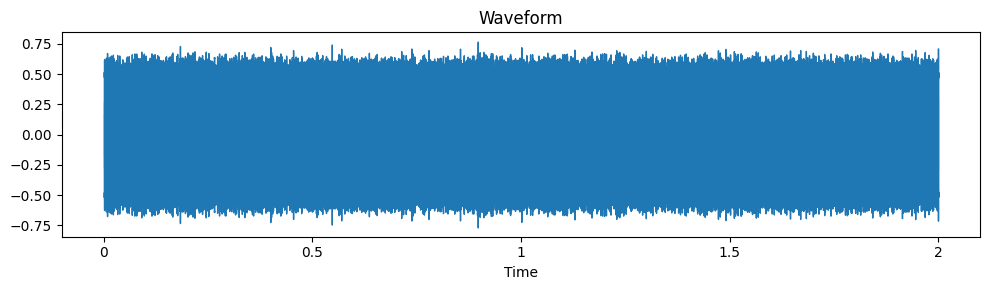

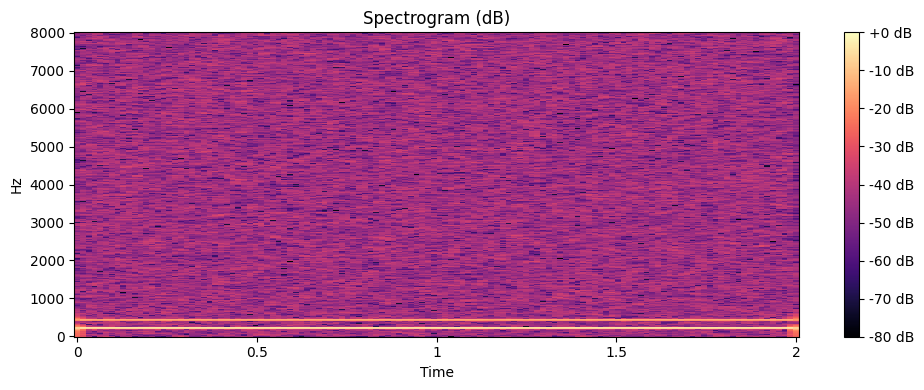

In [4]:
# Plot waveform
plt.figure(figsize=(10, 3))
librosa.display.waveshow(y, sr=sr)
plt.title('Waveform')
plt.tight_layout()
plt.show()

# Compute STFT and spectrogram
D = librosa.stft(y, n_fft=1024, hop_length=256)
S_db = librosa.amplitude_to_db(np.abs(D), ref=np.max)

plt.figure(figsize=(10, 4))
librosa.display.specshow(S_db, sr=sr, hop_length=256, x_axis='time', y_axis='hz')
plt.colorbar(format='%+2.0f dB')
plt.title('Spectrogram (dB)')
plt.tight_layout()
plt.show()

## Mel Spectrogram and MFCCs

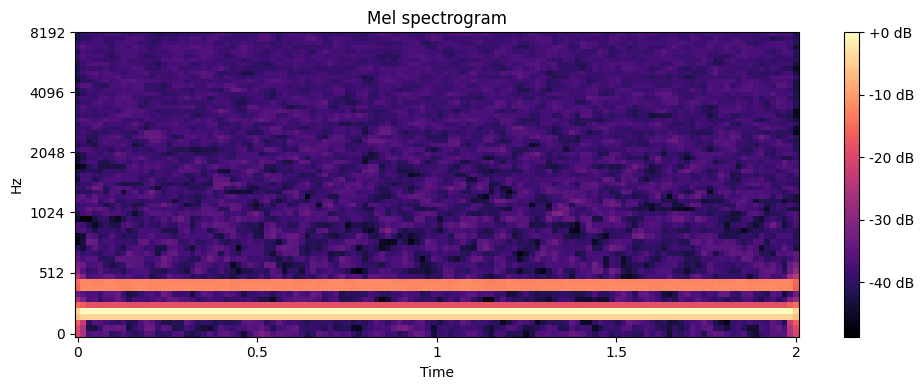

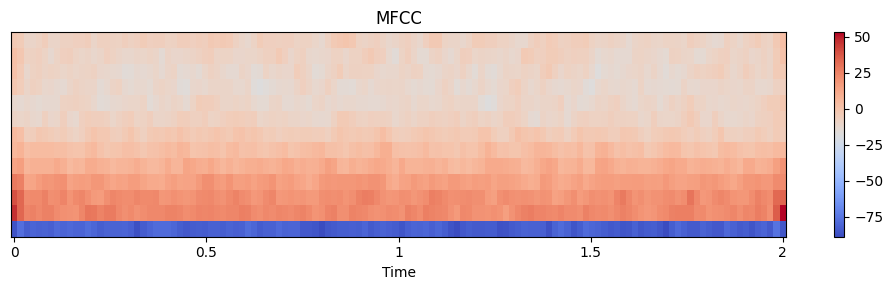

In [6]:
# Mel spectrogram
S = librosa.feature.melspectrogram(y=y, sr=sr, n_fft=1024, hop_length=256, n_mels=64)
S_db = librosa.power_to_db(S, ref=np.max)
plt.figure(figsize=(10, 4))
librosa.display.specshow(S_db, sr=sr, hop_length=256, x_axis='time', y_axis='mel')
plt.colorbar(format='%+2.0f dB')
plt.title('Mel spectrogram')
plt.tight_layout()
plt.show()

# MFCCs
mfccs = librosa.feature.mfcc(S=librosa.power_to_db(S), n_mfcc=13)
plt.figure(figsize=(10, 3))
librosa.display.specshow(mfccs, sr=sr, hop_length=256, x_axis='time')
plt.colorbar()
plt.title('MFCC')
plt.tight_layout()
plt.show()

## Save features to disk

In [7]:
import numpy as np
np.save('mel_spectrogram.npy', S)
np.save('mfccs.npy', mfccs)
print('Saved mel_spectrogram.npy and mfccs.npy in current directory')
# Download helper for Colab
try:
    from google.colab import files
    files.download('mel_spectrogram.npy')
except Exception:
    pass

Saved mel_spectrogram.npy and mfccs.npy in current directory


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Notes & Extensions
- Try loading real `.wav` files via upload or from Drive.
- Add pre-emphasis, silence trimming, or noise augmentation.
- Use saved features as inputs to an audio classifier (keyword spotting).